In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

df.head()

#displays first 5 rows in data frame 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:


df.info()
df["Class"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Class
0    284315
1       492
Name: count, dtype: int64

In [3]:
import numpy as np


descriptions = [
    "online purchase",
    "atm withdrawal",
    "international transaction",
    "merchant payment",
    "suspicious location",                  #like manually it is,which has possible transaction discription 
    "high value transaction",
    "late night transaction"
]

df["description"] = np.random.choice(descriptions, size=len(df))        #Randomly assigns one description to each transaction row
df[["Amount", "Class", "description"]].head()



#this makes the code run in numeric +in text format


,Amount,Class,description
0,149.62,0,international transaction
1,2.69,0,atm withdrawal
2,378.66,0,late night transaction
3,123.50,0,merchant payment
4,69.99,0,late night transaction


In [4]:
X_num = df.drop(columns=["Class", "description"]) #xnum is the new data frame here 
_           #stops data leakage           
y = df["Class"]


#therefore this avoids the data leaking here

In [5]:
from sklearn.model_selection import train_test_split

X_train_num, X_test_num, y_train, y_test = train_test_split(         #   X_train_num → numeric features for training
                                                                    # X_test_num → numeric features for evaluation 
                                                                       # y_train → labels for training
                                                                       # y_test → labels for evaluation
    X_num, #nmber matrix
    y, #labesls to not go this side that side
    test_size=0.2, #20% data for testing n rest to train
    random_state=42, #aany const works
    stratify=y #makes like all fraud case remain consistent in train n test 
)

#handles imbalanced data while class = balnced

In [6]:
df.shape
#return a tuple ie now of rows n columns in that daata set

(284807, 32)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Time         284807 non-null  float64
 1   V1           284807 non-null  float64
 2   V2           284807 non-null  float64
 3   V3           284807 non-null  float64
 4   V4           284807 non-null  float64
 5   V5           284807 non-null  float64
 6   V6           284807 non-null  float64
 7   V7           284807 non-null  float64
 8   V8           284807 non-null  float64
 9   V9           284807 non-null  float64
 10  V10          284807 non-null  float64
 11  V11          284807 non-null  float64
 12  V12          284807 non-null  float64
 13  V13          284807 non-null  float64
 14  V14          284807 non-null  float64
 15  V15          284807 non-null  float64
 16  V16          284807 non-null  float64
 17  V17          284807 non-null  float64
 18  V18          284807 non-

In [8]:
df["Class"].value_counts(normalize=True) * 100  #fraund n non fraud distribution n  100 is percent of coversion
                


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

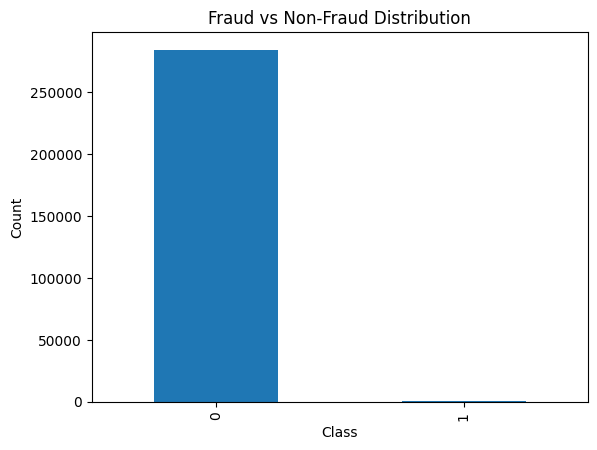

In [9]:
import matplotlib.pyplot as plt
#severe class imbalance in fraud detection

df["Class"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [10]:
import numpy as np

np.random.seed(42)

descriptions = [
    "online purchase",
    "atm withdrawal",
    "international transaction",
    "merchant payment",
    "suspicious location",
    "high value transaction",
    "late night transaction"
]

df["description"] = np.random.choice(descriptions, size=len(df))

df[["Amount", "Class", "description"]].head()


,Amount,Class,description
0,149.62,0,late night transaction
1,2.69,0,merchant payment
2,378.66,0,suspicious location
3,123.50,0,late night transaction
4,69.99,0,international transaction


In [11]:
from sklearn.preprocessing import StandardScaler #scales to variance of 1 n centers mean aront 0

scaler = StandardScaler()  #creates a obj
#obj learns stats   
X_train_num_scaled = scaler.fit_transform(X_train_num)#Numerical features are now:ComparableModel-friendlyBias-free
X_test_num_scaled = scaler.transform(X_test_num)
#imp for logestic regression n pca (v1 v18) features

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20,
    stop_words="english"
)#Keeps only the top 20 most important words

X_train_text = tfidf.fit_transform(df.loc[X_train_num.index, "description"])
                                    #Selects only training rows n Extracts the description coln
X_test_text = tfidf.transform(df.loc[X_test_num.index, "description"])


In [13]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_num_scaled, X_train_text])
X_test_final = hstack([X_test_num_scaled, X_test_text])

X_train_final.shape, X_test_final.shape


((227845, 44), (56962, 44))

In [14]:
from sklearn.linear_model import LogisticRegression
#Strong baseline for fraud
#Handles big datasets nicely
#gives risk score

log_reg = LogisticRegression(
    max_iter=1000,class_weight="balanced",                #tells how the model should act
    random_state=42
)

log_reg.fit(X_train_final, y_train)

y_pred = log_reg.predict(X_test_final)
#trains the models 
y_prob = log_reg.predict_proba(
    X_test_final)[:, 1]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
#focus on fraud ie class 1

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm
#???


array([[55446,  1418],
       [    8,    90]])

In [17]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

#checks how good iit superates fraud from non fraud


0.9701437658631263

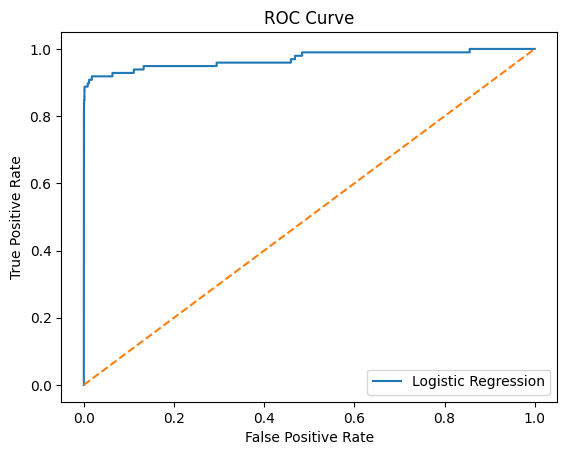

In [18]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
#roc_curve computes points needed to draw the ROC curve.

#matplotlib.pyplot is used for plotting the graph.

In [19]:
%whos



Variable                Type                  Data/Info
-------------------------------------------------------
LogisticRegression      type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
StandardScaler          type                  <class 'sklearn.preproces<...>ng._data.StandardScaler'>
TfidfVectorizer         type                  <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X_num                   DataFrame                         Time         <...>284807 rows x 30 columns]
X_test_final            coo_matrix            <COOrdinate sparse matrix<...>1, 38)	0.7071067811865476
X_test_num              DataFrame                         Time        V<...>[56962 rows x 30 columns]
X_test_num_scaled       ndarray               56962x30: 1708860 elems, type `float64`, 13670880 bytes (13.037567138671875 Mb)
X_test_text             csr_matrix            <Compressed Sparse Row sp<...>61, 8)	0.7071067811865476
X_train_final           coo_matrix            <C

In [20]:
from sklearn.linear_model import LogisticRegression

model_bal = LogisticRegression(
    class_weight={0: 1, 1: 5},
    max_iter=1000,
    random_state=42
)


In [21]:
model_bal.fit(X_train_num_scaled, y_train)




,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 5}"
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
y_pred = model_bal.predict(X_test_num_scaled)
y_prob = model_bal.predict_proba(X_test_num_scaled)[:, 1]


In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob)*100)
#prediction +risk score


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.82      0.76        98

    accuracy                           1.00     56962
   macro avg       0.85      0.91      0.88     56962
weighted avg       1.00      1.00      1.00     56962

[[56831    33]
 [   18    80]]
ROC-AUC: 96.66859991042


In [24]:
from sklearn.linear_model import LogisticRegression

model_bal = LogisticRegression( # creates logistic regression model with special settings
    class_weight={0: 1, 1: 5},  # penalize missed frauds more
    max_iter=1000,                 #Fraud (class 1) is 5× more important than normal transactions
    random_state=42  ,       #tries to give same result every time
    n_jobs=-1
)

model_bal.fit(X_train_num_scaled, y_train)





,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 5}"
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
results = {
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Confusion_Matrix": confusion_matrix(y_test, y_pred).tolist()
}

results
#saves the results

{'ROC_AUC': 0.9666859991041999, 'Confusion_Matrix': [[56831, 33], [18, 80]]}

In [26]:
%whos

Variable                Type                  Data/Info
-------------------------------------------------------
LogisticRegression      type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
StandardScaler          type                  <class 'sklearn.preproces<...>ng._data.StandardScaler'>
TfidfVectorizer         type                  <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X_num                   DataFrame                         Time         <...>284807 rows x 30 columns]
X_test_final            coo_matrix            <COOrdinate sparse matrix<...>1, 38)	0.7071067811865476
X_test_num              DataFrame                         Time        V<...>[56962 rows x 30 columns]
X_test_num_scaled       ndarray               56962x30: 1708860 elems, type `float64`, 13670880 bytes (13.037567138671875 Mb)
X_test_text             csr_matrix            <Compressed Sparse Row sp<...>61, 8)	0.7071067811865476
X_train_final           coo_matrix            <C

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,   #no of tree for now it is 100
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

#Imports Random Forest, an ensemble ML algorithm


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_prob_rf = rf.predict_proba(X_test_final)[:, 1]  #frad probability
threshold = 0.3
y_pred_thresh = (y_prob_rf >= threshold).astype(int)



In [29]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_thresh))
confusion_matrix(y_test, y_pred_thresh)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



array([[56858,     6],
       [   20,    78]])

In [30]:
import joblib

joblib.dump(rf, "fraud_model.pkl") #trains ml model
joblib.dump(scaler, "scaler.pkl") #number procesesing 
joblib.dump(tfidf, "tfidf.pkl")  #text procesing


['tfidf.pkl']

In [31]:
model_loaded = joblib.load("fraud_model.pkl")
model_loaded
#test for fast loading

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
X_train_num

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
265518,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32
180305,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99
42664,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10
198723,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10
82325,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233802,147710.0,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,0.995898,...,-0.174051,0.262526,0.884510,0.099141,0.275689,-0.195404,0.623598,-0.032455,-0.058552,5.99
85418,60764.0,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,0.452745,...,-0.225079,-0.072452,0.299172,0.110048,-0.615980,-0.425883,0.263968,-0.448445,0.045178,36.99
29062,35301.0,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,0.319684,...,-0.149402,-0.061991,-0.044629,-0.050485,0.400171,0.593314,-0.335160,0.031014,0.024886,45.42
13766,24413.0,1.280465,0.300586,0.333044,0.512720,0.065052,-0.145844,-0.145519,-0.091833,1.111187,...,-0.093783,-0.409934,-0.961351,0.033153,-0.560429,0.278428,0.089546,-0.059835,-0.005887,0.89
